In [45]:
# # Description
# 
# Prove that the Noise Reduction model works on a 2D polinomial.

# Add libs folder path to system variables to make the importation of local libraries easier.
# __________________________________________________________________________________________________
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [46]:
device = 'cpu'

In [47]:
def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6

In [66]:
data = np.arange(-5, 5, 0.001)
data_df = pd.DataFrame(data, columns=['x'])
data_df['y'] = polinomial_function(data_df['x'].values)

scaler = MinMaxScaler()
data_df = pd.DataFrame(scaler.fit_transform(data_df), columns=['x', 'y'])

In [67]:
data_df

,x,y
0,0.0000,1.000000
1,0.0001,0.999296
2,0.0002,0.998593
3,0.0003,0.997891
4,0.0004,0.997189
...,...,...
9995,0.9996,0.196380
9996,0.9997,0.196743
9997,0.9998,0.197107
9998,0.9999,0.197471


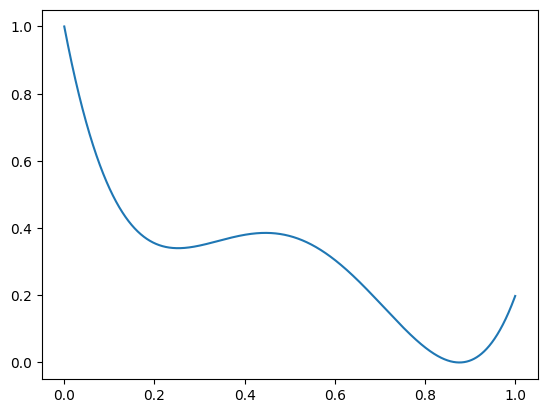

In [68]:
plt.plot(data_df['x'], data_df['y'])

In [69]:
# data_original = data_df.copy()
# for sigma in np.arange(0.01, 0.012, 0.01):
#     print(1)
#     df_noisy = add_gaussian_noise(
#         df=data_original.copy(),
#         columns=['x'],
#         mean=0.0,
#         std=sigma
#     )
#     data_df = pd.concat([data_df, df_noisy])

# # quitar en versión final
# data_df = df_noisy

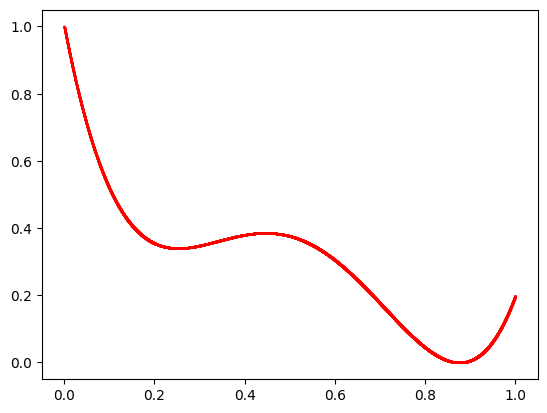

In [70]:
plt.scatter(data_df['x'], data_df['y'], s=1, c='r', alpha=0.5)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    data_df['x'].values,
    data_df['y'].values,
    test_size=0.2,
    random_state=42
)

In [72]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [73]:
denoiser = DenoisingAutoencoder(
    input_dim=1,
    latent_dim=32,
).to(device)

denoiser_v2 = DenoisingAutoencoder_v2(
    input_dim=1,
    hidden_dims=[256, 128, 64, 32],
    encoding_dim=8
).to(device)

n_layers = 3
hidden_layers = [(1, 64), (64, 32), (32, 1)]
dropout_layers = [0.1, 0.2, 0.0]
activation_func_layers = [nn.ReLU(), nn.ReLU(), nn.Identity()]
want_dropout = [False, True, False]
want_linear = [True, True, True]
want_activation = [True, True, False]

dense_nn = GridFullyDenseNN(
    n_layers, hidden_layers, dropout_layers, activation_func_layers,
    want_dropout, want_linear, want_activation
).to(device)

In [74]:
# Set model parameters and create the model Trainer object
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(denoiser.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=denoiser,
    train_generator=train_loader,
    val_generator=test_loader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=1000,
    checkpoints_path=os.path.join(
        CHECKPOINT_PATH, 'denoising_autoencoder'
    ),
)

In [75]:
# denoiser = torch.load(os.path.join(CHECKPOINT_PATH, 'denoising_autoencoder.pth'))

In [76]:
# Train the model
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   8%| | 84/1000 [01:30<16:30,  1.08s/epoch, Train loss: 3.681255801438965

Training stopped as validation loss did not improve for 15 epochs.


In [77]:
y_pred_noisy = trainer_basic.eval_dataloader(test_loader)
flattened_tensor = torch.cat(y_pred_noisy).view(-1)
len(flattened_tensor)

2000

In [78]:
# Show the metrics
gt_values = y_test
predicted_values = flattened_tensor.cpu().detach().numpy()

mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
# mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
nn_benchmark = {
    'nn': {
        "MSE: ": mse,
        "RMSE: ": rmse,
        "MAE: ": mae,
        # "MAPE: ": mape,
        "R2: ": r_squared
    }
}
nn_benchmark

{'nn': {'MSE: ': 8.238321314048061e-07,
  'RMSE: ': 0.0009076519880465233,
  'MAE: ': 0.0006301597444643361,
  'R2: ': 0.9999807704060156}}

In [127]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader


# Generate dataset
x_values = np.linspace(-10, 10, 1000)
y_values = polinomial_function(x_values)
data = pd.DataFrame({'x': x_values, 'y': y_values})

# Normalize data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
data['x'] = scaler_x.fit_transform(data[['x']])
data['y'] = scaler_y.fit_transform(data[['y']])

# Split data and create datasets
X_train, X_test, y_train, y_test = train_test_split(
    data['x'].values, data['y'].values, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Model configuration
n_layers = 3
hidden_layers = [(1, 64), (64, 32), (32, 1)]
dropout_layers = [0.1, 0.2, 0.0]
activation_func_layers = [nn.ReLU(), nn.ReLU(), nn.Identity()]
want_dropout = [False, True, False]
want_linear = [True, True, True]
want_activation = [True, True, False]

model = GridFullyDenseNN(
    n_layers, hidden_layers, dropout_layers, activation_func_layers,
    want_dropout, want_linear, want_activation
)
model = denoiser

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 1000
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        # batch_x = batch_x.to(device)
        # batch_y = batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.6f}')

# Evaluate the model
model.eval()
test_loss = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        test_predictions = model(batch_x)
        loss = criterion(test_predictions, batch_y)
        test_loss += loss.item()

print(f'Test Loss: {test_loss/len(test_loader):.6f}')


Epoch 100/1000, Loss: 0.0004


Epoch 200/1000, Loss: 0.0001
Epoch 300/1000, Loss: 0.0000
Epoch 400/1000, Loss: 0.0000
Epoch 500/1000, Loss: 0.0001
Epoch 600/1000, Loss: 0.0001
Epoch 700/1000, Loss: 0.0000
Epoch 800/1000, Loss: 0.0000
Epoch 900/1000, Loss: 0.0000
Epoch 1000/1000, Loss: 0.0000
Test Loss: 0.000007


In [130]:
y_pred_noisy = []
for x, y in test_loader:
    y_pred_noisy.append(model(x))
flattened_tensor = torch.cat(y_pred_noisy).view(-1)
len(flattened_tensor)

200

In [131]:
# Show the metrics
gt_values = y_test
predicted_values = flattened_tensor.cpu().detach().numpy()

mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
# mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
nn_benchmark = {
    'nn': {
        "MSE: ": mse,
        "RMSE: ": rmse,
        "MAE: ": mae,
        # "MAPE: ": mape,
        "R2: ": r_squared
    }
}
nn_benchmark

{'nn': {'MSE: ': 6.955457786412271e-06,
  'RMSE: ': 0.0026373201903470635,
  'MAE: ': 0.0018239231215178863,
  'R2: ': 0.9998573627662053}}